<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-34-polynomial-regression?scriptVersionId=343444451" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---

# 🤖 ML 34 — Polynomial Regression

### **Modeling Non-Linear Relationships with Polynomial Features**

---

In [126]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [127]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

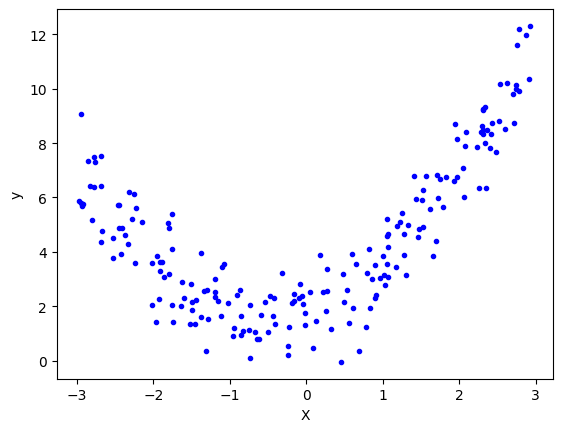

In [128]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [129]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X, y, random_state=42)

In [130]:
# Applying linear regression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [131]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.17862266897777423

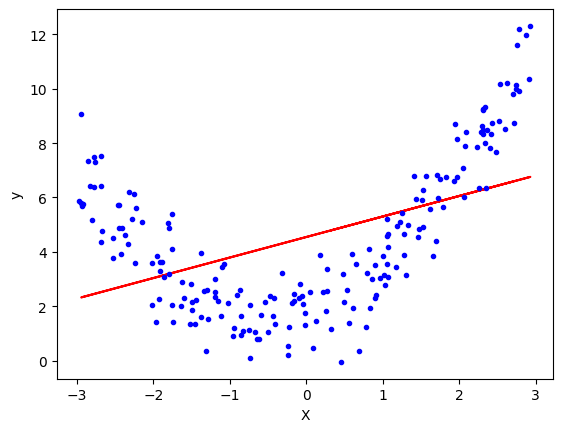

In [132]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [133]:
# Applying Polynomial Linear Regression
# Degree 2

poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [134]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [135]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.8817952761864496

In [136]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.80852301 0.81269647]]
[2.0518459]


In [137]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

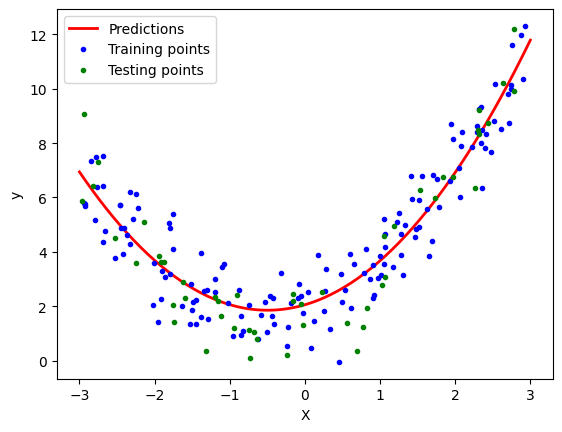

In [138]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [139]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

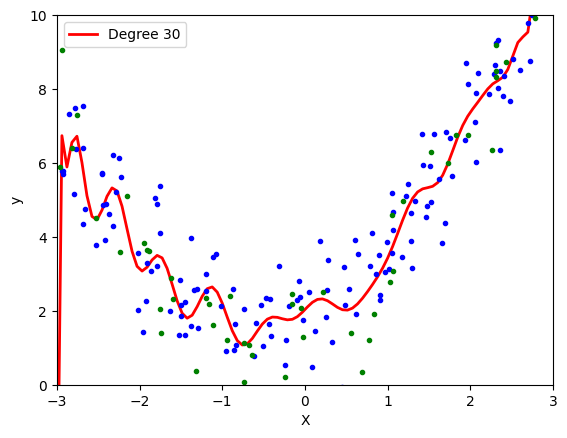

In [140]:
polynomial_regression(30)

In [141]:
poly.powers_

array([[0],
       [1],
       [2]])

In [142]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [143]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [144]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [145]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [146]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [147]:
# Create polynomial features
poly = PolynomialFeatures(degree=5)

X_multi_trans = poly.fit_transform(X_multi)

print(X_multi_trans.shape)
# (100, 496)


# Train Linear Regression on polynomial features
lr_poly = LinearRegression()

lr_poly.fit(X_multi_trans, z)


# Transform the grid points
X_test_multi = poly.transform(final)

print(X_test_multi.shape)
# (100, 496)


# Predict using polynomial model
z_final = lr_poly.predict(X_test_multi).reshape(10, 10)

(100, 21)
(100, 21)


In [148]:
fig = px.scatter_3d(
    x=x.ravel(),
    y=y.ravel(),
    z=z.ravel()
)

fig.add_trace(
    go.Surface(
        x=x_input,
        y=y_input,
        z=z_final
    )
)

fig.update_layout(
    scene=dict(
        zaxis=dict(range=[0, 35])
    )
)

fig.show()